# Module 2: Data Preprocessing and Feature Engineering  
This notebook transforms raw data into **predictive features**.  
The main focus is on applying **Cross-Sectional Ranking** to normalize data across different stocks at the same point in time.

> **Environment Note:** This notebook was developed and tested on a **Linux-based environment**. If you are running it on Windows, some file paths (e.g., `src/features.py`) may need to use backslashes, and shell commands prefixed with `!` may not work as expected. Consider using [WSL](https://learn.microsoft.com/en-us/windows/wsl/) or running it inside a Linux container for the smoothest experience.

In [1]:
%pip install pandas numpy matplotlib vnstock xgboost pyarrow scikit-learn optuna streamlit google-generativeai gplearn torch requests scipy
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import sklearn
import time
import os
import sys
import seaborn as sns
from scipy.stats import spearmanr

project_root = os.path.abspath("/kaggle/input/datasets/phmhuyphongp/modules-vn100")

if project_root not in sys.path:
    sys.path.append(project_root)

import src.features as ft
import src.evaluation as ev
import src.models as md 
import src.feature_search as fs
import src.alpha_mining as alpm
from config import candidate_features

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.0/279.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 57.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
Note: you may need to restart the kernel to use updated packages.


In [2]:

FILE_URL = "/kaggle/input/datasets/phmhuyphongp/vn100-dataset/market_data.parquet"
df_raw = pd.read_parquet(FILE_URL)
df_raw.head()

,date,open,high,low,close,volume,Symbol
0,2016-01-04,3.16,3.16,3.13,3.14,36439,ACB
1,2016-01-05,3.13,3.13,3.08,3.10,47676,ACB
2,2016-01-06,3.10,3.11,3.08,3.11,40589,ACB
3,2016-01-07,3.08,3.10,3.03,3.05,94027,ACB
4,2016-01-08,3.03,3.05,3.03,3.05,84809,ACB


## 2.1 Feature Selection Rationale
In this project, I select 8 primary features categorized into three groups to capture the Vietnamese stock market's dynamics:

* **Momentum Indicators**: `log_ret_1m`, `log_ret_3m`, `log_ret_1y` - These capture the trend-following behavior of investors.
* **Risk & Volatility**: `volatility_3m`, `volatility_shock_monthly` - These measure the systematic and unsystematic risk levels.
* **Trend & Liquidity**: `dist_SMA_100`, `RSI_14`, `volume_surge_monthly` - These identify overbought/oversold conditions and abnormal trading interest.

### Cross-Sectional Ranking
Instead of using absolute values, I apply **Cross-Sectional Ranking** to every feature. This technique normalizes data across 100 tickers at each timestamp, effectively removing "Market Beta" and focusing on the relative strength (Alpha) of each stock within the VN100 basket.

In [3]:
# Define your features and target
features = candidate_features

In [ ]:
wq = alpm.WorldQuantAlphas(df_raw)
wq_cols_df = wq.generate_all()
for col in wq_cols_df.columns:
    df_raw[col] = wq_cols_df[col]
df = ft.build_features(df_raw)
df = ft.build_targets(df)
df = ft.target_generating_ranking(df)
#df,new_features = ft.apply_cross_sectional_ranking(df,features)
#features = features + new_features

Generating WorldQuant Alphas...


/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/alpha_mining.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return -1 * g.apply(
/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/alpha_mining.py:107: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr = df_sorted.groupby('Symbol').apply(
Dropping 518 date(s) with fewer than 50 stocks after NaN removal.


In [5]:
# Always filter to rows with a valid target before IC analysis
df_ic = df.dropna(subset=['next_1m_ret']).copy()

feature_ic = {}
for col in features:
    ic_vals = df_ic.groupby('date').apply(
        lambda x: spearmanr(x[col], x['next_1m_ret']).statistic,
        include_groups=False
    )
    feature_ic[col] = {
        'ic_mean': ic_vals.mean(),
        'ic_std': ic_vals.std(),
        'ic_ir': ic_vals.mean() / ic_vals.std() if ic_vals.std() > 0 else 0,
        'positive_rate': (ic_vals > 0).mean()
    }

ic_df = pd.DataFrame(feature_ic).T 

In [6]:
ic_vals = df_ic.groupby('date').apply(
    lambda x: spearmanr(
        x[[col, 'next_1m_ret']].dropna()[col],
        x[[col, 'next_1m_ret']].dropna()['next_1m_ret']
    ).statistic,
    include_groups=False
)
# Also filter out dates where correlation was undefined (< 2 valid pairs)
ic_vals = ic_vals.dropna()

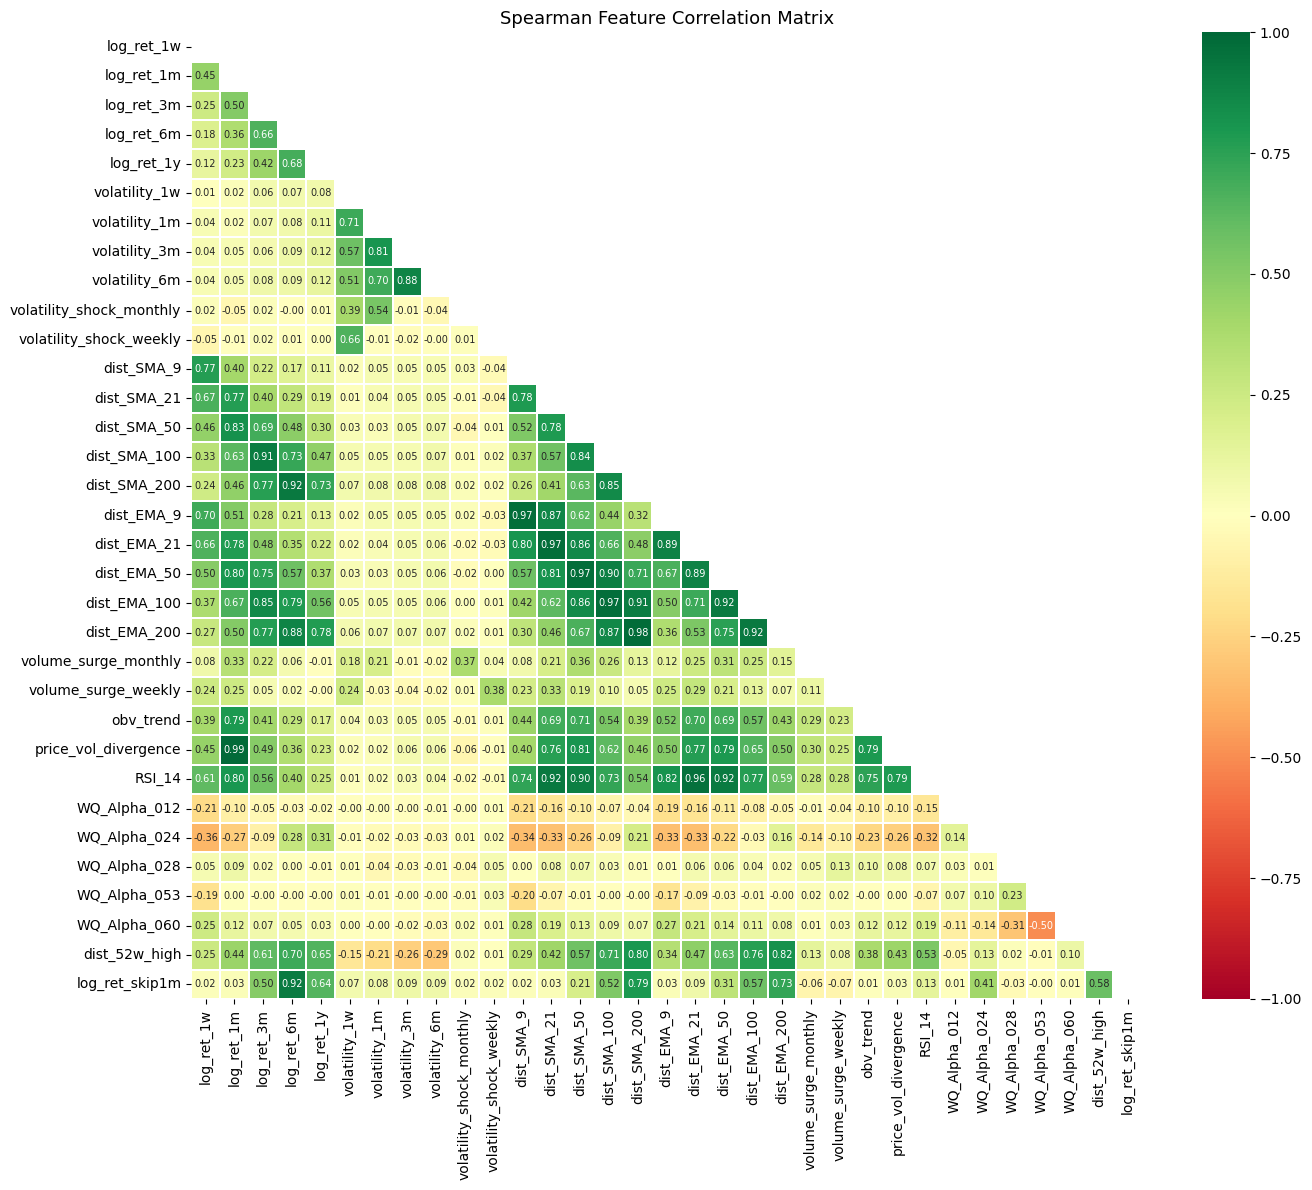

In [7]:
# 1. Compute Spearman correlation matrix
df_clean = df[features].dropna()
corr_matrix, _ = spearmanr(df_clean)
corr_df = pd.DataFrame(corr_matrix, index=features, columns=features)

# 2. Draw heatmap
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_df, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    ax=ax,
    annot_kws={'size': 7}
)
ax.set_title('Spearman Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

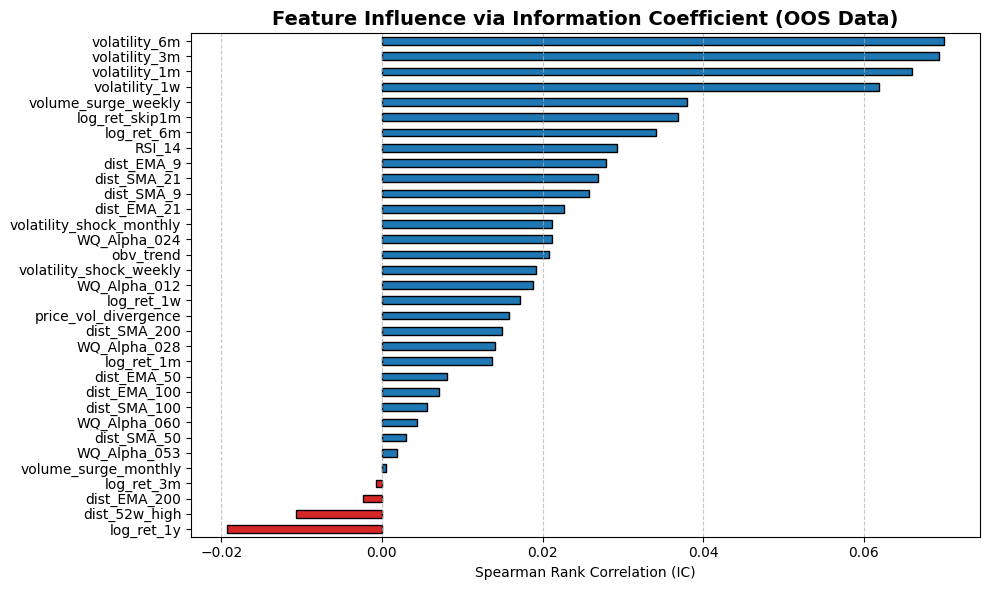

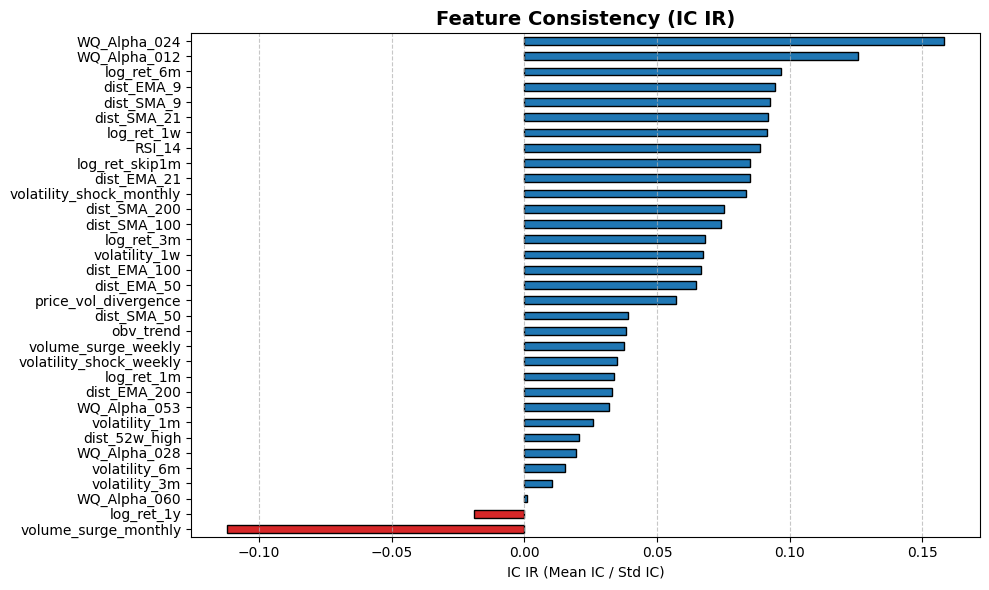

,IC Mean,IC Std,IC IR
volume_surge_monthly,-0.017493,0.156190,-0.111997
log_ret_1y,-0.004215,0.224647,-0.018764
WQ_Alpha_060,0.000171,0.170524,0.001003
volatility_3m,0.002848,0.272415,0.010455
volatility_6m,0.004332,0.284511,0.015227
WQ_Alpha_028,0.002621,0.134249,0.019523
dist_52w_high,0.005309,0.257780,0.020594
volatility_1m,0.006360,0.244363,0.026028
WQ_Alpha_053,0.004519,0.141338,0.031972
dist_EMA_200,0.007927,0.239188,0.033143


In [8]:
ic_ir_results = ev.plot_feature_ic_and_ir(df,features)
ic_ir_results

In [19]:
# 3. Identify redundant pairs and decide which to drop
THRESHOLD = 0.75
to_drop = set()

for i in range(len(features)):
    for j in range(i + 1, len(features)):
        feat_i = features[i]
        feat_j = features[j]
        if abs(corr_df.loc[feat_i, feat_j]) >= THRESHOLD:
            # Keep whichever has higher IC IR
            ir_i = ic_df.loc[feat_i, 'ic_ir']
            ir_j = ic_df.loc[feat_j, 'ic_ir']
            drop = feat_j if ir_i >= ir_j else feat_i
            to_drop.add(drop)
            print(f"Corr({feat_i}, {feat_j}) = {corr_df.loc[feat_i, feat_j]:.2f} "
                  f"→ drop '{drop}'")

clean_features = [f for f in features if f not in to_drop] 
print(f"\nKept {len(clean_features)}/{len(features)} features")
print(clean_features)

Corr(log_ret_1w, dist_SMA_9) = 0.77 → drop 'log_ret_1w'
Corr(log_ret_1m, dist_SMA_21) = 0.77 → drop 'log_ret_1m'
Corr(log_ret_1m, dist_SMA_50) = 0.83 → drop 'log_ret_1m'
Corr(log_ret_1m, dist_EMA_21) = 0.78 → drop 'log_ret_1m'
Corr(log_ret_1m, dist_EMA_50) = 0.80 → drop 'log_ret_1m'
Corr(log_ret_1m, obv_trend) = 0.79 → drop 'log_ret_1m'
Corr(log_ret_1m, price_vol_divergence) = 0.99 → drop 'log_ret_1m'
Corr(log_ret_1m, RSI_14) = 0.80 → drop 'log_ret_1m'
Corr(log_ret_3m, dist_SMA_100) = 0.91 → drop 'log_ret_3m'
Corr(log_ret_3m, dist_SMA_200) = 0.77 → drop 'log_ret_3m'
Corr(log_ret_3m, dist_EMA_50) = 0.75 → drop 'dist_EMA_50'
Corr(log_ret_3m, dist_EMA_100) = 0.85 → drop 'dist_EMA_100'
Corr(log_ret_3m, dist_EMA_200) = 0.77 → drop 'dist_EMA_200'
Corr(log_ret_6m, dist_SMA_200) = 0.92 → drop 'dist_SMA_200'
Corr(log_ret_6m, dist_EMA_100) = 0.79 → drop 'dist_EMA_100'
Corr(log_ret_6m, dist_EMA_200) = 0.88 → drop 'dist_EMA_200'
Corr(log_ret_6m, log_ret_skip1m) = 0.92 → drop 'log_ret_skip1m'
Corr(

In [21]:
clean_features = ic_ir_results.loc[
    clean_features                                    # row filter: already deduplicated
].loc[
    np.abs(ic_ir_results.loc[clean_features, "IC IR"]) > 0.02  # row filter: IC IR threshold
].index.tolist()
clean_features

['log_ret_6m',
 'volatility_1w',
 'volatility_1m',
 'volatility_shock_monthly',
 'volatility_shock_weekly',
 'dist_EMA_9',
 'volume_surge_monthly',
 'volume_surge_weekly',
 'WQ_Alpha_012',
 'WQ_Alpha_024',
 'WQ_Alpha_053']